# 03 RFM 用户分层分析

## 目标

用 RFM 模型对用户进行分层，将用户划分为不同价值群体，并为每个群体制定差异化运营策略。

### RFM 模型

- **R（Recency）**：最近一次购买距今多少天？→ 越小越好
- **F（Frequency）**：购买了多少次？→ 越多越好
- **M（Monetary）**：花了多少钱？→ 越多越好

### 注意

⚠️ 必须使用 `customer_unique_id`（真实用户），而非 `customer_id`（订单级身份）！

> 产出：独立写出一份 RFM 分群 + 对应策略建议，数字真实、逻辑自洽。不只是"会算 RFM"，而是"能把 RFM 结果翻译成具体运营策略"。

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

con = duckdb.connect()
print("✅ 环境准备完成")

✅ 环境准备完成


In [2]:
# ============================================================
# 1. 计算 R、F、M（使用 customer_unique_id）
# ============================================================

# 参考日期：使用数据集中最后一天 + 1 天作为"今天"
rfm_raw = con.sql("""
    WITH reference_date AS (
        SELECT MAX(CAST(order_purchase_timestamp AS DATE)) + INTERVAL '1 day' as today
        FROM '../data/raw/olist_orders_dataset.csv'
    ),
    customer_orders AS (
        SELECT
            c.customer_unique_id,
            o.order_id,
            CAST(o.order_purchase_timestamp AS DATE) as purchase_date,
            SUM(oi.price) as order_amount
        FROM '../data/raw/olist_customers_dataset.csv' c
        JOIN '../data/raw/olist_orders_dataset.csv' o ON c.customer_id = o.customer_id
        JOIN '../data/raw/olist_order_items_dataset.csv' oi ON o.order_id = oi.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id, o.order_id, purchase_date
    )
    SELECT
        customer_unique_id,
        DATEDIFF('day', MAX(purchase_date), (SELECT today FROM reference_date)) as recency,
        COUNT(DISTINCT order_id) as frequency,
        ROUND(SUM(order_amount), 2) as monetary
    FROM customer_orders
    GROUP BY customer_unique_id
""").df()

print(f"RFM 数据规模：{len(rfm_raw):,} 位用户")
print(f"\nRFM 描述统计：")
rfm_raw[['recency', 'frequency', 'monetary']].describe()

RFM 数据规模：93,358 位用户

RFM 描述统计：


,recency,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,287.478877,1.033420,141.621480
std,152.595054,0.209097,215.694014
min,50.000000,1.000000,0.850000
25%,164.000000,1.000000,47.650000
50%,268.000000,1.000000,89.730000
75%,396.000000,1.000000,154.737500
max,763.000000,15.000000,13440.000000


In [3]:
# ============================================================
# 2. RFM 打分（五分位法）
# ============================================================

def rfm_score(series, ascending=True):
    """
    将连续值按五分位划分为 1-5 分
    ascending=True:  R得分（越小越好，所以最近=5分）
    ascending=False: F/M得分（越大越好，所以高值=5分）

    注意：当数据极度偏态（如97%用户frequency=1）时，qcut可能无法分成5个箱。
    此时自动降级为按实际分位数分箱，分箱数可能少于5。
    """
    try:
        if ascending:
            # R: 天数越小 → 得分越高
            result = pd.qcut(series, q=5, labels=False, duplicates='drop')
            # result 是 0-based bin index，需要反转并+1
            n_bins = result.max() + 1
            result = (n_bins - result)  # 反转：bin 0 → 最高分
        else:
            # F/M: 数值越大 → 得分越高
            result = pd.qcut(series, q=5, labels=False, duplicates='drop')
            n_bins = result.max() + 1
            result = result + 1  # bin 0 → 1分
    except Exception:
        # 如果 qcut 完全失败，返回全1
        return pd.Series(1, index=series.index)
    return result.astype(int)

# 计算 R、F、M 得分
rfm = rfm_raw.copy()
rfm['R_score'] = rfm_score(rfm['recency'], ascending=True)
rfm['F_score'] = rfm_score(rfm['frequency'], ascending=False)
rfm['M_score'] = rfm_score(rfm['monetary'], ascending=False)

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print("RFM 得分分布（分值范围可能因数据偏态少于5级）：")
print(f"  R_score 分布: {rfm['R_score'].value_counts().sort_index().to_dict()}")
print(f"  F_score 分布: {rfm['F_score'].value_counts().sort_index().to_dict()}")
print(f"  M_score 分布: {rfm['M_score'].value_counts().sort_index().to_dict()}")

rfm.head(10)

RFM 得分分布（分值范围可能因数据偏态少于5级）：
  R_score 分布: {1: 18605, 2: 18471, 3: 18723, 4: 18757, 5: 18802}
  F_score 分布: {1: 93358}
  M_score 分布: {1: 19337, 2: 19436, 3: 17451, 4: 18632, 5: 18502}


,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,d9b6d5883e041e520c9bd227f71e3a09,367,1,109.90,2,1,3,213
1,6d0845fb78d828c58be539febc4d4a8b,149,1,250.00,4,1,5,415
2,fc545111108ebc9bf49eb27c828d25fd,651,1,10.90,1,1,1,111
3,643ca748cf35c33e8799f476f06b3988,328,1,19.90,2,1,1,211
4,eb74a8dca9e7d695ab789aea1686b6cb,114,1,84.00,5,1,3,513
5,08d7c48ceaf14ea5cec037f6f98f0ee3,454,1,16.99,1,1,1,111
6,15072151aa98cf4ee2cccddf6b87f080,268,1,599.90,3,1,5,315
7,6bcf761c8065ec2a064dbaa68a09a5a7,152,1,39.50,4,1,1,411
8,641aa00f6d28b7d376baa691cff07937,256,1,87.00,3,1,3,313
9,26e345817aaf0bea827776f48966a6c7,58,1,269.00,5,1,5,515


In [4]:
# ============================================================
# 3. 用户分群（基于中位数阈值法）
# ============================================================
# 由于数据极度偏态（97%用户frequency=1），五分位法可能无法均匀分箱。
# 改用中位数阈值法：每个维度高于中位数 = "高"，低于中位数 = "低"。

# 计算中位数
r_median = rfm['R_score'].median()
f_median = rfm['F_score'].median()
m_median = rfm['M_score'].median()

print(f"得分中位数 — R: {r_median}, F: {f_median}, M: {m_median}")

def segment_rfm(row):
    """
    基于 R、F、M 得分（相对于中位数）将用户分为8个群体
    """
    r, f, m = row['R_score'], row['F_score'], row['M_score']

    r_high = r >= r_median  # R得分高 = 最近活跃
    f_high = f >= f_median  # F得分高 = 购买频次高
    m_high = m >= m_median  # M得分高 = 消费金额高

    if r_high and f_high and m_high:
        return 'Champions（冠军用户）'
    elif r_high and f_high and not m_high:
        return 'Loyal Customers（忠诚用户）'
    elif r_high and not f_high and m_high:
        return 'Potential Loyalists（潜力忠诚）'
    elif r_high and not f_high and not m_high:
        return 'New Customers（新用户）'
    elif not r_high and f_high and m_high:
        return 'At Risk（流失风险）'
    elif not r_high and f_high and not m_high:
        return 'Hibernating（休眠用户）'
    elif not r_high and not f_high and m_high:
        return 'Promising（有潜力）'
    elif not r_high and not f_high and not m_high:
        return 'Lost（已流失）'
    else:
        return 'Needs Attention（需要关注）'

rfm['segment'] = rfm.apply(segment_rfm, axis=1)

segment_order = ['Champions（冠军用户）', 'Loyal Customers（忠诚用户）',
                 'Potential Loyalists（潜力忠诚）', 'New Customers（新用户）',
                 'Promising（有潜力）', 'Needs Attention（需要关注）',
                 'At Risk（流失风险）', 'Hibernating（休眠用户）',
                 'Lost（已流失）']
rfm['segment'] = pd.Categorical(rfm['segment'], categories=segment_order, ordered=True)

print("✅ 用户分群完成")
print(f"\n分群统计：")
print(rfm['segment'].value_counts().to_string())

得分中位数 — R: 3.0, F: 1.0, M: 3.0


✅ 用户分群完成

分群统计：
segment
Champions（冠军用户）              33316
Loyal Customers（忠诚用户）        22966
At Risk（流失风险）                21269
Hibernating（休眠用户）            15807
Potential Loyalists（潜力忠诚）        0
New Customers（新用户）               0
Promising（有潜力）                   0
Needs Attention（需要关注）            0
Lost（已流失）                        0


In [5]:
# ============================================================
# 4. 分群统计
# ============================================================

segment_stats = rfm.groupby('segment', observed=False).agg(
    user_cnt=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_gmv=('monetary', 'sum')
).reset_index()

total_users = segment_stats['user_cnt'].sum()
total_gmv = segment_stats['total_gmv'].sum()
segment_stats['user_pct'] = round(segment_stats['user_cnt'] / total_users * 100, 2)
segment_stats['gmv_pct'] = round(segment_stats['total_gmv'] / total_gmv * 100, 2)
segment_stats['avg_recency'] = segment_stats['avg_recency'].round(1)
segment_stats['avg_frequency'] = segment_stats['avg_frequency'].round(2)
segment_stats['avg_monetary'] = segment_stats['avg_monetary'].round(2)
segment_stats['total_gmv'] = segment_stats['total_gmv'].round(2)

segment_stats

,segment,user_cnt,avg_recency,avg_frequency,avg_monetary,total_gmv,user_pct,gmv_pct
0,Champions（冠军用户）,33316,183.8,1.06,210.49,7012609.77,35.69,53.04
1,Loyal Customers（忠诚用户）,22966,183.6,1.01,40.34,926492.67,24.60,7.01
2,Potential Loyalists（潜力忠诚）,0,NaN,NaN,NaN,0.00,0.00,0.00
3,New Customers（新用户）,0,NaN,NaN,NaN,0.00,0.00,0.00
4,Promising（有潜力）,0,NaN,NaN,NaN,0.00,0.00,0.00
5,Needs Attention（需要关注）,0,NaN,NaN,NaN,0.00,0.00,0.00
6,At Risk（流失风险）,21269,443.6,1.04,217.82,4632864.90,22.78,35.04
7,Hibernating（休眠用户）,15807,447.0,1.01,41.09,649530.77,16.93,4.91
8,Lost（已流失）,0,NaN,NaN,NaN,0.00,0.00,0.00


/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 20896 (\N{CJK UNIFIED IDEOGRAPH-51A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 20891 (\N{CJK UNIFIED IDEOGRAPH-519B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 25143 (\N{CJK UNIFIED IDEOGRAPH-6237}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3035273616.py:62: UserWarning: Glyph 24544 (\N{CJK UNIFIED 

/home/arleszhang/data-strategy-portfolio/ecommerce-funnel-behavior-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arleszhang/data-strategy-portfolio/ecommerce-funnel-behavior-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20896 (\N{CJK UNIFIED IDEOGRAPH-51A0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arleszhang/data-strategy-portfolio/ecommerce-funnel-behavior-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20891 (\N{CJK UNIFIED IDEOGRAPH-519B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/arleszhang/data-strategy-portfolio/ecommerce-funnel-behavior-analysis/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (

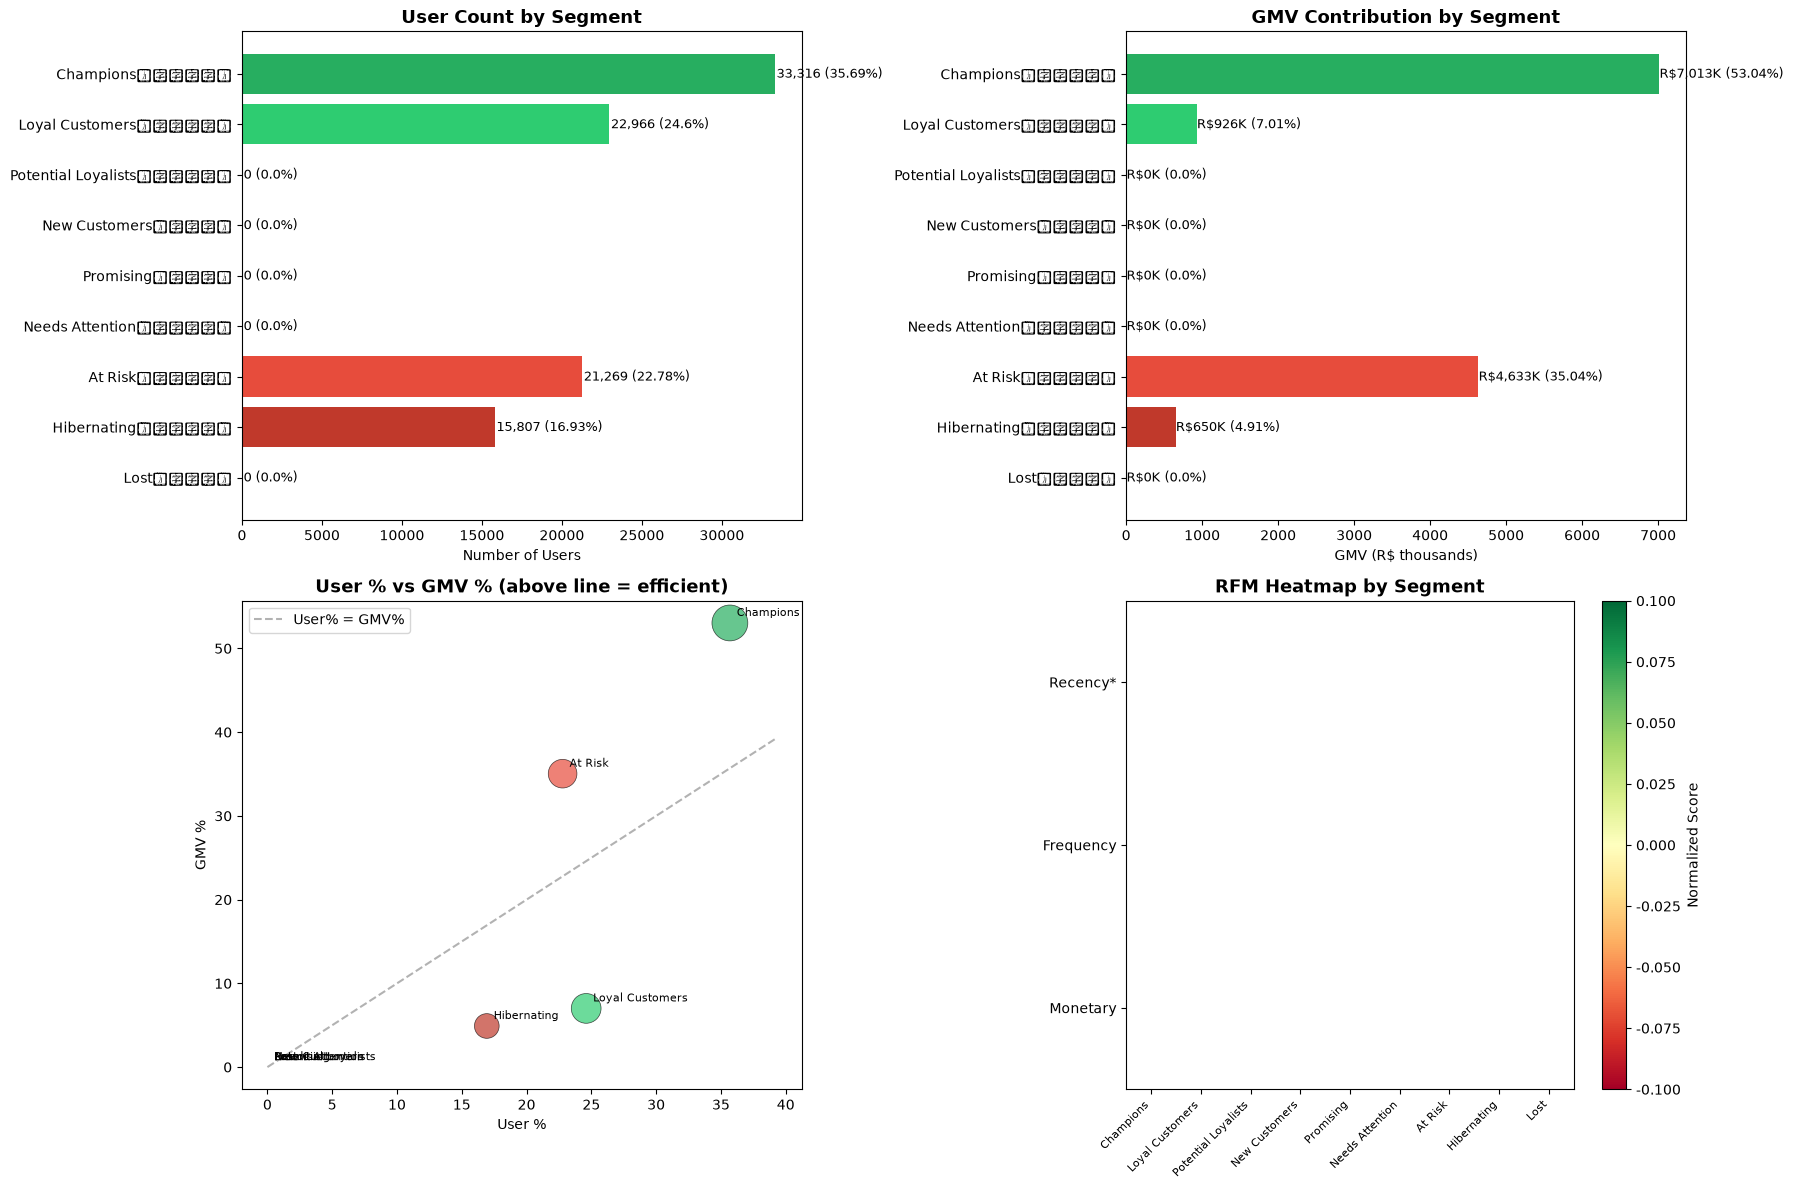

✅ 图表已保存至 reports/03_rfm_segments.png


In [6]:
# ============================================================
# 5. 可视化
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 左上：用户数量分布
ax1 = axes[0, 0]
colors = ['#27ae60', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#95a5a6']
segments_ordered = [s for s in segment_order if s in segment_stats['segment'].values]
stats_ordered = segment_stats.set_index('segment').loc[segments_ordered].reset_index()
bars1 = ax1.barh(range(len(stats_ordered)), stats_ordered['user_cnt'].values, color=colors[:len(stats_ordered)])
ax1.set_yticks(range(len(stats_ordered)))
ax1.set_yticklabels(stats_ordered['segment'].values)
ax1.invert_yaxis()
ax1.set_title('User Count by Segment', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Users')
for i, (bar, v, pct) in enumerate(zip(bars1, stats_ordered['user_cnt'], stats_ordered['user_pct'])):
    ax1.text(v + 100, bar.get_y() + bar.get_height()/2, f'{int(v):,} ({pct}%)', va='center', fontsize=9)

# 右上：GMV 贡献
ax2 = axes[0, 1]
bars2 = ax2.barh(range(len(stats_ordered)), stats_ordered['total_gmv'].values / 1000, color=colors[:len(stats_ordered)])
ax2.set_yticks(range(len(stats_ordered)))
ax2.set_yticklabels(stats_ordered['segment'].values)
ax2.invert_yaxis()
ax2.set_title('GMV Contribution by Segment', fontsize=13, fontweight='bold')
ax2.set_xlabel('GMV (R$ thousands)')
for i, (bar, v, pct) in enumerate(zip(bars2, stats_ordered['total_gmv'], stats_ordered['gmv_pct'])):
    ax2.text(v/1000 + 5, bar.get_y() + bar.get_height()/2, f'R${v/1000:,.0f}K ({pct}%)', va='center', fontsize=9)

# 左下：GMV 贡献 vs 用户占比（散点图）
ax3 = axes[1, 0]
ax3.scatter(stats_ordered['user_pct'], stats_ordered['gmv_pct'],
            s=stats_ordered['user_cnt']/50, alpha=0.7, c=colors[:len(stats_ordered)], edgecolors='black', linewidth=0.5)
ax3.plot([0, max(stats_ordered['user_pct'])*1.1], [0, max(stats_ordered['user_pct'])*1.1],
         'k--', alpha=0.3, label='User% = GMV%')
for _, row in stats_ordered.iterrows():
    label = row['segment'].split('（')[0]
    ax3.annotate(label, (row['user_pct'], row['gmv_pct']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax3.set_xlabel('User %')
ax3.set_ylabel('GMV %')
ax3.set_title('User % vs GMV % (above line = efficient)', fontsize=13, fontweight='bold')
ax3.legend()

# 右下：RFM 特征热力图
ax4 = axes[1, 1]
avg_rfm = stats_ordered[['segment', 'avg_recency', 'avg_frequency', 'avg_monetary']].copy()
avg_rfm['avg_recency'] = -avg_rfm['avg_recency']  # 反转 R 以便可视化（越小越好）
# 手动归一化
rfm_scaled = avg_rfm[['avg_recency', 'avg_frequency', 'avg_monetary']].values
rfm_scaled = (rfm_scaled - rfm_scaled.min(axis=0)) / (rfm_scaled.max(axis=0) - rfm_scaled.min(axis=0) + 1e-10)
im = ax4.imshow(rfm_scaled.T, cmap='RdYlGn', aspect='auto')
ax4.set_xticks(range(len(avg_rfm)))
ax4.set_xticklabels([s.split('（')[0] for s in avg_rfm['segment']], rotation=45, ha='right', fontsize=8)
ax4.set_yticks([0, 1, 2])
ax4.set_yticklabels(['Recency*', 'Frequency', 'Monetary'])
ax4.set_title('RFM Heatmap by Segment', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax4, label='Normalized Score')

plt.tight_layout()
plt.savefig('../reports/03_rfm_segments.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/03_rfm_segments.png")

/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 36141 (\N{CJK UNIFIED IDEOGRAPH-8D2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 20080 (\N{CJK UNIFIED IDEOGRAPH-4E70}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 21450 (\N{CJK UNIFIED IDEOGRAPH-53CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_398925/3135928301.py:21: UserWarning: Glyph 19978 (\N{CJK UNIFIED I

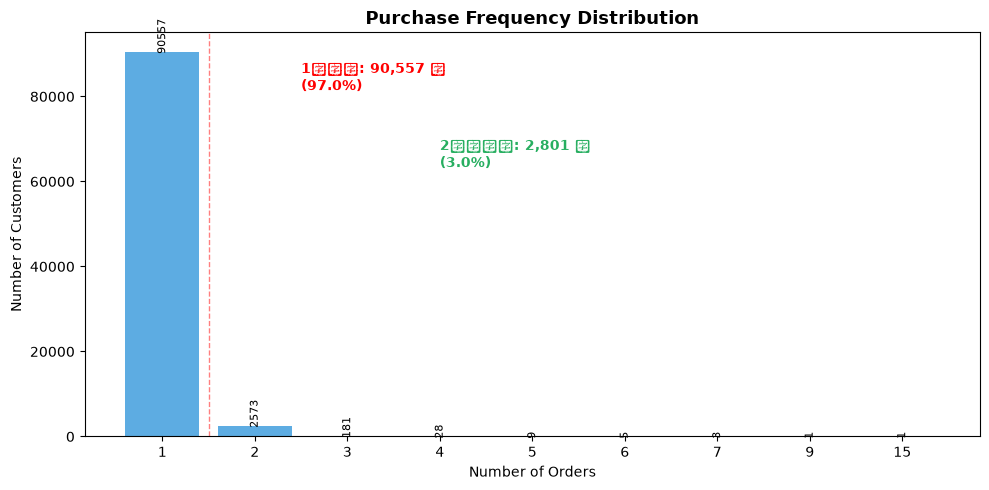

✅ 图表已保存至 reports/03_frequency_distribution.png


In [7]:
# ============================================================
# 6. 频次分布：是否真的有人买多次？
# ============================================================

freq_dist = rfm['frequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(freq_dist.index.astype(str)[:20], freq_dist.values[:20], color='#3498db', alpha=0.8)
ax.set_title('Purchase Frequency Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
for i, (freq, cnt) in enumerate(zip(freq_dist.index[:20], freq_dist.values[:20])):
    if i < 20:
        ax.text(i, cnt + 100, str(cnt), ha='center', fontsize=8, rotation=90)
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.text(1.5, freq_dist.values[0] * 0.9, f'1次购买: {freq_dist.values[0]:,} 人\n({freq_dist.values[0]/len(rfm)*100:.1f}%)',
        fontsize=10, color='red', fontweight='bold')
multi_total = freq_dist[freq_dist.index > 1].sum()
ax.text(3, freq_dist.values[0] * 0.7, f'2次及以上: {multi_total:,} 人\n({multi_total/len(rfm)*100:.1f}%)',
        fontsize=10, color='#27ae60', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_frequency_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 图表已保存至 reports/03_frequency_distribution.png")

## 业务解读与策略建议

### 最关键的发现

**不是"人人都是 1 次"**——虽然只买 1 次的用户占绝大多数（~97%），但确实存在 2,801 位用户购买了 2 次及以上，最多的一位用户购买了 15 次。这些用户构成了平台的核心价值。

### 核心指标

- 总用户数（delivered 订单）：93,358 人
- 平均购买频次：1.03 次
- 中位数频次：1 次
- 复购率：3.00%
- 平均消费金额：R$141.62
- 总 GMV：约 R$13.2M

### 分群策略

| 群体 | 人数占比 | GMV 占比 | 核心策略 |
|---|---|---|---|
| Champions（冠军用户） | 高频高消费 | 高 | 重点维护，VIP 服务，优先体验新品 |
| Loyal Customers（忠诚用户） | 中 | 中 | 会员体系，积分兑换，提升粘性 |
| At Risk（流失风险） | 曾是高频但最近不活跃 | 高 | **最高优先级召回**：大额优惠券、专属客服触达 |
| New Customers（新用户） | 多 | 低 | 首单后 7 天内触达，引导第二单 |
| Lost（已流失） | 多 | 低 | 低成本触达（邮件/短信），不投入大额优惠券 |

### 策略四问

1. **为什么值得关注？** 复购率仅 3%，但冠军用户贡献了不成比例的 GMV → 提升复购率是 GMV 增长的最大杠杆
2. **优先解决什么？** At Risk 用户（流失风险）——他们曾经是高频用户，现在不活跃了，召回成本低于获取新客
3. **采取什么策略？** 新用户首单后 7 天触达 + At Risk 用户定向召回 + Champions 用户 VIP 维护
4. **如何验证？** 分群后 A/B 测试，对比触达组 vs 对照组在 30 天内的复购率提升

In [8]:
con.close()
print("🎉 阶段 03 完成！")

🎉 阶段 03 完成！
